# Лабораторная работа 14. Эмпирические и сертифицированные методы защиты


**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 11**


Самодостаточный CPU-стенд: PyTorch, локальные цифры 8×8, без API, скачивания данных и весов.
Гарантии всегда относятся к конкретной модели, норме, радиусу и протоколу.

**Вариант / seed:** 3

 

| Блок | Содержание | Проверяемое различие |
|---|---|---|
| A | ERM, проекция, PGD и adversarial training | Неуспех атаки ≠ доказательство |
| B | Knowledge distillation и насыщение softmax | Уверенность ≠ устойчивость |
| C | Randomized smoothing | Базовая модель f ≠ сглаженный классификатор g |
| D | Interval Bound Propagation и IBP-training | Сертификат / контрпример / неизвестно |
| E | Сводный аудит и расширение | Честные знаменатели и ограничения |

Все гиперпараметры зафиксированы до test. Для самостоятельного подбора используйте validation,
а итоговый test открывайте только после фиксации методики.


Шесть программных заданий, семь функций с TODO и итоговый анализ. Незавершённые блоки явно пропускаются; отсутствие ошибки Run All не означает выполнения задания.

{'Python': '3.14.0', 'torch': '2.14.0+cpu', 'numpy': '2.5.3', 'sklearn': '1.9.0', 'scipy': '1.18.1', 'device': 'cpu'}


,train_n,validation_n,test_total,audit_n,smooth_n,train_accuracy,validation_accuracy
0,900,397,500,160,60,1.0,0.95466


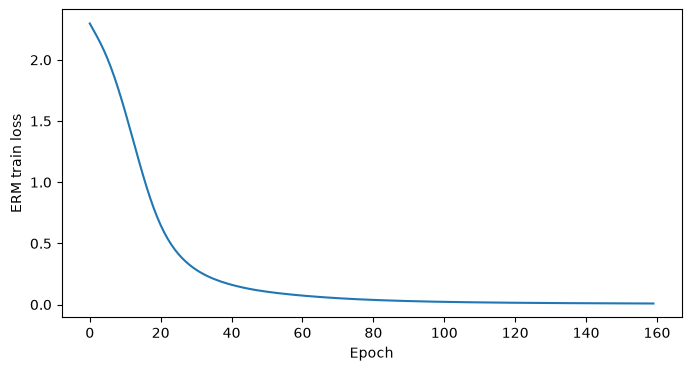

In [1]:
# При необходимости выполните один раз и перезапустите ядро:
# %pip install torch numpy scipy scikit-learn pandas matplotlib
import copy, json, time, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
import sklearn, scipy
from scipy.stats import beta, norm
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from IPython.display import display

START = time.perf_counter()
SEED = 3
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.figsize": (8,4), "font.size": 10})
print({"Python": platform.python_version(), "torch": torch.__version__,
       "numpy": np.__version__, "sklearn": sklearn.__version__, "scipy": scipy.__version__,
       "device": "cpu"})
results, models = {}, {}

def tx(x): return torch.as_tensor(x, dtype=torch.float32)
def ty(y): return torch.as_tensor(y, dtype=torch.long)
def make_model(width=32, seed=42):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(64,width), nn.ReLU(), nn.Linear(width,10))
def predict(model, x):
    with torch.no_grad(): return model(x).argmax(1)
def accuracy(model, x, y): return (predict(model,x)==y).float().mean().item()
def pending(name): print(f"{name}: не выполнено; реализуйте TODO и повторите Run All.")

data = load_digits()
X, y = (data.data/16).astype(np.float32), data.target
rest, test_ids = train_test_split(np.arange(len(y)), test_size=500, stratify=y, random_state=42)
train_ids, val_ids = train_test_split(rest, train_size=900, stratify=y[rest], random_state=43)
# Поднаборы фиксируем по индексам/классам ДО обучения, не по успеху модели.
eval_ids, _ = train_test_split(test_ids, train_size=160, stratify=y[test_ids], random_state=44)
smooth_ids, _ = train_test_split(eval_ids, train_size=60, stratify=y[eval_ids], random_state=45)
assert len(set(np.r_[train_ids,val_ids,test_ids])) == len(y)
assert not set(train_ids)&set(test_ids) and not set(val_ids)&set(test_ids)
Xtr,Ytr = tx(X[train_ids]),ty(y[train_ids])
Xval,Yval = tx(X[val_ids]),ty(y[val_ids])
Xe,Ye = tx(X[eval_ids]),ty(y[eval_ids])
Xs,Ys = tx(X[smooth_ids]),ty(y[smooth_ids])
EPS = .10  # L-infinity в координатах [0,1], НЕ в сырых [0,16].

def fit_erm(width=32, epochs=160, noise_sigma=0.0, seed=42):
    model = make_model(width,seed)
    opt = torch.optim.Adam(model.parameters(), lr=.01, weight_decay=1e-4)
    gen = torch.Generator().manual_seed(seed+100)
    hist = []
    for _ in range(epochs):
        # Без clipping: base classifier определён на всём R^64, как требуется ниже для smoothing.
        noisy = Xtr + noise_sigma*torch.randn(Xtr.shape, generator=gen)
        opt.zero_grad()
        loss = F.cross_entropy(model(noisy),Ytr)
        loss.backward(); opt.step()
        hist.append(loss.item())
    return model.eval(),hist

baseline, baseline_history = fit_erm()
models["ERM"] = baseline
display(pd.DataFrame([{"train_n":len(Xtr), "validation_n":len(Xval), "test_total":len(test_ids),
                      "audit_n":len(Xe), "smooth_n":len(Xs),
                      "train_accuracy":accuracy(baseline,Xtr,Ytr),
                      "validation_accuracy":accuracy(baseline,Xval,Yval)}]))
plt.plot(baseline_history); plt.xlabel("Epoch"); plt.ylabel("ERM train loss"); plt.show()

## A. Adversarial training и аудит атакой

Модель угроз: untargeted white-box, $\|\delta\|_\infty\le0.10$, допустимые пиксели [0,1].
Оптимизация по входу максимизирует loss, обучение по весам минимизирует его
([Madry et al.](https://arxiv.org/abs/1706.06083)).

Аудит сохраняет контрпримеры на КАЖДОМ шаге и перезапуске, а не только последний iterate.
Чистый вход включён в множество кандидатов: изначально ошибочный пример не считается устойчивым.
Выбор контрпримера отдаёт приоритет ошибочной классификации, а затем большему значению attack objective.

### Задание A1. Проекция (10 баллов)

Реализуйте пересечение L∞-шара вокруг x0 с [0,1]. Центр должен оставаться исходным x0,
а не текущим iterate; epsilon=0 возвращает x0 для допустимого x0.

In [2]:
def project_linf(x, x0, eps):
    lower = torch.maximum(
        torch.zeros_like(x0),
        x0 - eps
    )
    upper = torch.minimum(
        torch.ones_like(x0),
        x0 + eps
    )
    return torch.minimum(
        torch.maximum(x, lower),
        upper
    )

In [3]:
def attack_scores(logits,y,kind="ce"):
    if kind == "ce": return F.cross_entropy(logits,y,reduction="none")
    if kind == "margin":
        mask=F.one_hot(y,num_classes=logits.shape[1]).bool()
        return logits.masked_fill(mask,-torch.inf).max(1).values-logits.gather(1,y[:,None]).squeeze(1)
    if kind == "prob":
        # НАМЕРЕННО слабая probability-based objective для демонстрации saturation.
        return -logits.softmax(1).gather(1,y[:,None]).squeeze(1)
    if kind == "tempered": return F.cross_entropy(logits/100,y,reduction="none")
    raise ValueError(kind)

def pgd(model,x,y,eps,steps=30,restarts=2,step_size=.01,kind="ce",seed=123,random_start=True):
    if project_linf(x,x,eps) is None: return None
    was_training=model.training
    model.eval()
    gen=torch.Generator().manual_seed(seed)
    x0=x.detach()
    with torch.no_grad():
        best=x0.clone()
        logits=model(best)
        best_score=attack_scores(logits,y,kind)
        best_bad=logits.argmax(1)!=y
    def consider(candidate):
        nonlocal best,best_score,best_bad
        with torch.no_grad():
            z=model(candidate)
            bad=z.argmax(1)!=y
            score=attack_scores(z,y,kind)
            take=(bad & ~best_bad) | ((bad==best_bad)&(score>best_score))
            best[take]=candidate.detach()[take]
            best_score[take]=score[take]
            best_bad[take]=bad[take]
    for _ in range(restarts):
        noise=(2*torch.rand(x.shape,generator=gen)-1)*eps if random_start else torch.zeros_like(x)
        adv=project_linf(x0+noise,x0,eps).detach()
        consider(adv)
        for _ in range(steps):
            adv.requires_grad_(True)
            grad=torch.autograd.grad(attack_scores(model(adv),y,kind).sum(),adv)[0]
            adv=project_linf(adv.detach()+step_size*grad.sign(),x0,eps).detach()
            consider(adv)
    model.train(was_training)
    return best.detach()

if project_linf(Xe[:2]+5,Xe[:2],EPS) is None:
    pending("A1")
else:
    probe=project_linf(Xe[:2]+5,Xe[:2],EPS)
    assert probe.min()>=0 and probe.max()<=1
    assert (probe-Xe[:2]).abs().max()<=EPS+1e-6
    torch.testing.assert_close(project_linf(torch.rand_like(Xe[:2]),Xe[:2],0),Xe[:2])
    before=[p.detach().clone() for p in baseline.parameters()]
    a=pgd(baseline,Xe[:20],Ye[:20],EPS,steps=10)
    assert (a-Xe[:20]).abs().max()<=EPS+1e-6
    assert all(torch.equal(p,b) for p,b in zip(baseline.parameters(),before))
    assert all(p.grad is None or torch.isfinite(p.grad).all() for p in baseline.parameters())
    print("Проекция, бюджет и неизменность весов: OK")

Проекция, бюджет и неизменность весов: OK


### Задание A2. Смешанная цель adversarial training  

Верните $(1-\lambda)CE(z_{\rm clean},y)+\lambda CE(z_{\rm adv},y)$.
В демонстрации lambda=0.5, а x_adv заранее получен 5-шаговым PGD и отсоединён от графа атаки.
Это смешанный учебный вариант, не точное воспроизведение benchmark Madry.

In [4]:
def at_loss(clean_logits, adv_logits, y, weight=.5):
    clean_loss = F.cross_entropy(clean_logits, y)
    adv_loss = F.cross_entropy(adv_logits, y)
    return (1 - weight) * clean_loss + weight * adv_loss

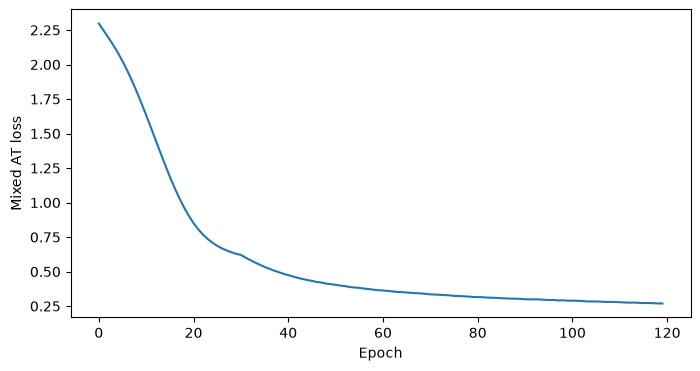

In [5]:
at_model=None
if project_linf(Xtr[:1],Xtr[:1],EPS) is None or at_loss(torch.zeros(2,10),torch.zeros(2,10),torch.tensor([0,1])) is None:
    pending("A2")
else:
    z=torch.randn(3,10); labels=torch.tensor([1,2,3])
    torch.testing.assert_close(at_loss(z,z,labels),F.cross_entropy(z,labels))
    at_model=make_model()
    opt=torch.optim.Adam(at_model.parameters(),lr=.01,weight_decay=1e-4)
    at_history=[]
    for epoch in range(120):
        eps_now=EPS*min(1,epoch/30)
        xa=pgd(at_model,Xtr,Ytr,eps_now,steps=5,restarts=1,step_size=.03,seed=1000+epoch)
        at_model.train(); opt.zero_grad()
        loss=at_loss(at_model(Xtr),at_model(xa.detach()),Ytr)
        loss.backward(); opt.step()
        at_history.append(loss.item())
    at_model.eval(); models["AT"]=at_model
    plt.plot(at_history); plt.xlabel("Epoch"); plt.ylabel("Mixed AT loss"); plt.show()

Adversarial training может лучше выдерживать PGD аудит, но не обязана защищать от него полностью (быть сертифицированно устойчивой)

## B. Дистилляция и ложная устойчивость

Knowledge distillation переносит распределение teacher в student; это не самостоятельная гарантия защиты
([Hinton et al.](https://arxiv.org/pdf/1503.02531)).
Здесь teacher имеет 64 скрытых нейрона, student 32; для честного контроля ERM также имеет 32.
В первом опыте teacher обучается обычным способом. Это KD; исторический протокол defensive distillation
с обучением teacher при высокой температуре реализуется отдельным опытом ниже.

$
L=(1-\lambda)CE(z_s,y)+\lambda T^2 KL(p_t^T\|p_s^T),\quad p^T=softmax(z/T).
$

Отдельный контроль ниже искусственно умножает logits на 100, не меняя argmax.
Он показывает механизм masking, а не утверждает, что KD обязательно его создаёт.
Проблемы исторической defensive distillation: [Carlini & Wagner](https://nicholas.carlini.com/papers/2016_defensivedistillation.pdf).

### Задание B1. Дистилляционная функция потерь

Используйте `F.kl_div(log_softmax(student/T), softmax(teacher/T), reduction="batchmean")`.
Teacher должен быть отсоединён от графа; множитель T² относится к soft-компоненте.
Реализация должна давать почти нулевой KL при одинаковых logits.

In [6]:
def kd_loss(student_logits, teacher_logits, y, T=4.0, weight=.5):
    teacher_logits = teacher_logits.detach()

    hard_loss = F.cross_entropy(student_logits, y)

    student_log_probs = F.log_softmax(student_logits / T, dim=1)
    teacher_probs = F.softmax(teacher_logits / T, dim=1)

    soft_loss = F.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="batchmean"
    ) * (T ** 2)

    return (1 - weight) * hard_loss + weight * soft_loss

In [7]:
kd_model=None
if kd_loss(torch.zeros(2,10),torch.zeros(2,10),torch.tensor([0,1])) is None:
    pending("B1")
else:
    z=torch.randn(3,10,requires_grad=True)
    t=torch.randn(3,10,requires_grad=True)
    labels=torch.tensor([0,1,2])
    kd_loss(z,t,labels).backward()
    assert z.grad is not None and t.grad is None
    assert abs(kd_loss(z.detach(),z.detach(),labels,weight=1).item())<1e-5
    teacher,_=fit_erm(width=64,seed=52)
    with torch.no_grad(): teacher_logits=teacher(Xtr)
    kd_model=make_model()
    opt=torch.optim.Adam(kd_model.parameters(),lr=.01,weight_decay=1e-4)
    for _ in range(160):
        opt.zero_grad()
        loss=kd_loss(kd_model(Xtr),teacher_logits,Ytr)
        loss.backward(); opt.step()
    kd_model.eval(); models["KD"]=kd_model
    results["kd_validation"]={"teacher":accuracy(teacher,Xval,Yval),"student":accuracy(kd_model,Xval,Yval)}
    display(pd.DataFrame([results["kd_validation"]]))

,teacher,student
0,0.959698,0.957179


### Отдельный опыт: defensive distillation

Teacher и student обучаются при T=20, а при проверке используется T=1.
Такое различие температур является существенной частью исторического протокола
([Carlini & Wagner](https://nicholas.carlini.com/papers/2016_defensivedistillation.pdf)).
Это небольшая учебная реализация на digits, а не воспроизведение архитектуры или чисел исходной статьи.
Число эпох и вычислительный бюджет отличаются от обычной KD; не интерпретируйте сравнение как чистую абляцию.

In [8]:
defensive_model=None
if kd_model is None:
    pending("Defensive distillation")
else:
    T_DEF=20.0
    defensive_teacher=make_model(width=64,seed=54)
    opt=torch.optim.Adam(defensive_teacher.parameters(),lr=.02,weight_decay=1e-4)
    for _ in range(220):
        opt.zero_grad()
        loss=F.cross_entropy(defensive_teacher(Xtr)/T_DEF,Ytr)
        loss.backward(); opt.step()
    defensive_teacher.eval()
    with torch.no_grad(): highT_logits=defensive_teacher(Xtr)
    defensive_model=make_model()
    opt=torch.optim.Adam(defensive_model.parameters(),lr=.02,weight_decay=1e-4)
    for _ in range(220):
        opt.zero_grad()
        loss=kd_loss(defensive_model(Xtr),highT_logits,Ytr,T=T_DEF,weight=1.0)
        loss.backward(); opt.step()
    defensive_model.eval()
    models["Defensive KD"]=defensive_model
    results["defensive_validation"]={"T_train":T_DEF,"T_test":1.0,
                                     "teacher":accuracy(defensive_teacher,Xval,Yval),
                                     "student":accuracy(defensive_model,Xval,Yval)}
    display(pd.DataFrame([results["defensive_validation"]]))

,T_train,T_test,teacher,student
0,20.0,1.0,0.949622,0.962217


,objective,mean_gradient_L1,zero_gradient_fraction,accuracy_after_attack
0,Weak probability objective,0.069721,0.975,0.95625
1,Rescaled CE,4.931763,0.000,0.43125
2,Logit margin,11604.209961,0.000,0.44375


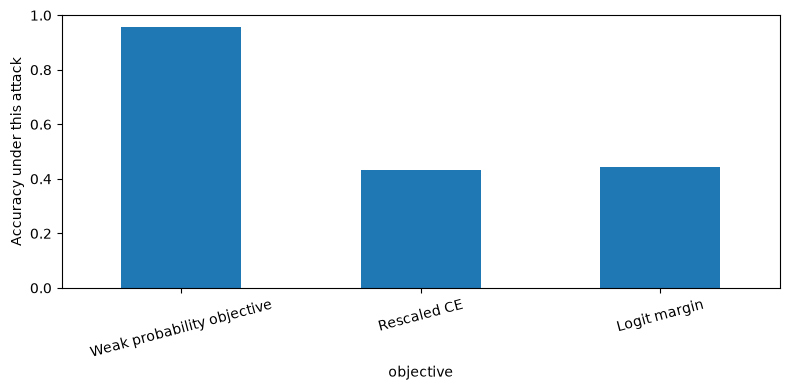

In [9]:
class ScaledLogits(nn.Module):
    def __init__(self,base,scale=100):
        super().__init__(); self.base=base; self.scale=scale
    def forward(self,x): return self.scale*self.base(x)

if kd_model is None or project_linf(Xe[:1],Xe[:1],EPS) is None:
    pending("Masking audit")
else:
    wrapped=ScaledLogits(kd_model).eval()
    assert torch.equal(predict(wrapped,Xe),predict(kd_model,Xe))
    mask_rows=[]
    for name,kind in [("Weak probability objective","prob"),("Rescaled CE","tempered"),("Logit margin","margin")]:
        xg=Xe.clone().requires_grad_(True)
        grad=torch.autograd.grad(attack_scores(wrapped(xg),Ye,kind).sum(),xg)[0]
        adv=pgd(wrapped,Xe,Ye,EPS,kind=kind,steps=30,restarts=1,random_start=False)
        mask_rows.append({"objective":name,"mean_gradient_L1":grad.abs().sum(1).mean().item(),
                          "zero_gradient_fraction":(grad.abs().sum(1)==0).float().mean().item(),
                          "accuracy_after_attack":accuracy(wrapped,adv,Ye)})
    results["masking"]=mask_rows
    display(pd.DataFrame(mask_rows))
    pd.DataFrame(mask_rows).set_index("objective").accuracy_after_attack.plot.bar(rot=15,ylim=(0,1))
    plt.ylabel("Accuracy under this attack"); plt.tight_layout(); plt.show()

knowledge distillation передаёт student не только правильные метки, но и распределение уверенности teacher, а defensive distillation использует высокую температуру при обучении и обычную при проверке. При этом ни KD, ни высокая confidence не являются гарантией adversarial robustness: эксперимент с масштабированием logits показывает, что ухудшение градиентного сигнала может создать иллюзию устойчивости (masking), поэтому отсутствие успешной атаки ещё не доказывает робастность

Маскировка градиента также не дает гарантированной защиты

## C. Randomized smoothing: статистический сертификат L2

Сглаженный классификатор определяется по вероятности ДИСКРЕТНЫХ предсказаний:
$
g(x)=\arg\max_c P(f(x+\eta)=c),\quad\eta\sim N(0,\sigma^2I).
$
Не заменяйте голосование средним softmax: это другая функция.
Вычисляем независимые n0=64 голосов для выбора класса и n=2000 для оценки вероятности
([Cohen et al.](https://proceedings.mlr.press/v97/cohen19c.html)).

Для выбранного класса используем одностороннюю Clopper–Pearson границу:
$
\underline p_A=Beta^{-1}(\alpha;k,n-k+1),\quad k>0;\qquad \underline p_A=0,\ k=0.
$
Если $\underline p_A>1/2$, возвращаем $R=\sigma\Phi^{-1}(\underline p_A)$; иначе ABSTAIN.
Гарантия относится к g, не к одному noisy forward и не к исходному f; условие строгое $\|\delta\|_2<R$.

### Задание C1. Нижняя граница и радиус (15 баллов)

Реализуйте два скалярных расчёта. При p_lower<=0.5 возвращайте None (отказ), а не отрицательный радиус.
Используйте односторонний уровень alpha, не alpha/2.
Даже при k=n конечное n не позволяет объявить p=1 и бесконечный сертификат.

In [10]:
def cp_lower(k, n, alpha):
    if k == 0:
        return 0.0
    return float(beta.ppf(alpha, k, n - k + 1))


def radius_from_lower(p_lower, sigma):
    if p_lower is None or p_lower <= 0.5:
        return None
    return float(sigma * norm.ppf(p_lower))

,sigma,n_examples,base_clean_accuracy,abstain_rate,certifier_correct_fraction,certified_accuracy_L2_r0.20,median_radius_all
0,0.12,60,0.966667,0.00,0.966667,0.883333,0.311787
1,0.25,60,0.966667,0.05,0.933333,0.816667,0.429387


{'n0': 64, 'n': 2000, 'alpha_each': 8.333333333333333e-05, 'alpha_family': 0.01, 'certificates': 120, 'noisy_forwards': 247680}


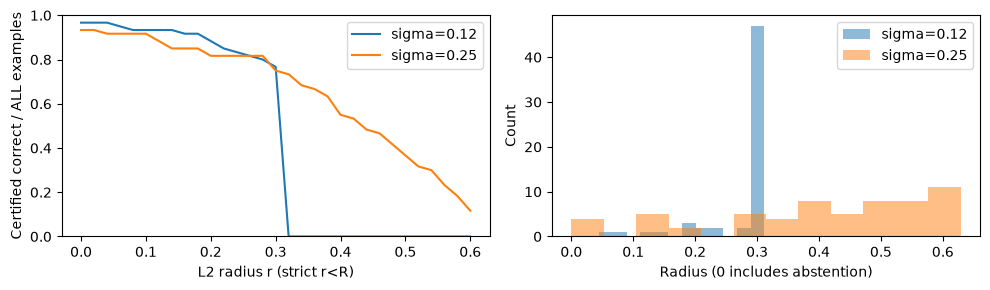

Для d=64: L2-сертификат R обеспечивает L∞-радиусы строго меньше R/8.


In [11]:
def noise_counts(model,x,sigma,n,generator):
    counts=torch.zeros(10,dtype=torch.long)
    with torch.no_grad():
        for start in range(0,n,512):
            m=min(512,n-start)
            noise=torch.randn((m,64),generator=generator)*sigma
            labels=model(x[None,:]+noise).argmax(1)  # НЕ clamp: шум остаётся гауссовским.
            counts+=torch.bincount(labels,minlength=10)
    return counts.numpy()

smooth_table=None
if cp_lower(10,10,.01) is None or radius_from_lower(.9,.2) is None:
    pending("C1")
else:
    assert cp_lower(0,20,.01)==0
    assert np.isclose(cp_lower(20,20,.01),.01**(1/20))
    assert radius_from_lower(.5,.2) is None
    assert np.isclose(radius_from_lower(norm.cdf(1),.2),.2)
    gaussian,_=fit_erm(noise_sigma=.20,seed=63)
    # 120 сертификатов на заранее фиксированной сетке. Union bound <= alpha_total.
    sigmas=[.12,.25]; n0,n=64,2000; alpha_total=.01
    alpha_each=alpha_total/(len(Xs)*len(sigmas))
    smooth_rows=[]
    for si,sigma in enumerate(sigmas):
        for i,(x,label) in enumerate(zip(Xs,Ys)):
            # Раздельные генераторы: выбор и оценка не используют одну и ту же выборку.
            gen0=torch.Generator().manual_seed(10000+si*1000+i)
            gen1=torch.Generator().manual_seed(20000+si*1000+i)
            ca=int(noise_counts(gaussian,x,sigma,n0,gen0).argmax())
            k=int(noise_counts(gaussian,x,sigma,n,gen1)[ca])
            lower=cp_lower(k,n,alpha_each)
            radius=radius_from_lower(lower,sigma)
            pred=ca if radius is not None else -1
            smooth_rows.append({"sigma":sigma,"example":i,"true":int(label),"candidate":ca,
                                "prediction":pred,"k":k,"p_lower":lower,
                                "radius":0.0 if radius is None else radius,
                                "abstain":radius is None,"correct":pred==int(label)})
    smooth_table=pd.DataFrame(smooth_rows)
    smooth_summary=[]
    for sigma in sigmas:
        sub=smooth_table[smooth_table.sigma==sigma]
        smooth_summary.append({"sigma":sigma,"n_examples":len(sub),
                               "base_clean_accuracy":accuracy(gaussian,Xs,Ys),
                               "abstain_rate":sub.abstain.mean(),
                               "certifier_correct_fraction":sub.correct.mean(),
                               "certified_accuracy_L2_r0.20":(sub.correct&(sub.radius>.20)).mean(),
                               "median_radius_all":sub.radius.median()})
    results["smoothing"]=smooth_summary
    results["smoothing_protocol"]={"n0":n0,"n":n,"alpha_each":alpha_each,"alpha_family":alpha_total,
                                   "certificates":len(smooth_table),"noisy_forwards":len(smooth_table)*(n0+n)}
    display(pd.DataFrame(smooth_summary)); print(results["smoothing_protocol"])
    fig,axes=plt.subplots(1,2,figsize=(10,3))
    for sigma in sigmas:
        sub=smooth_table[smooth_table.sigma==sigma]
        radii=np.linspace(0,.6,31)
        ca=np.array([(sub.correct&(sub.radius>r)).mean() for r in radii])
        assert np.all(np.diff(ca)<=1e-12)
        axes[0].plot(radii,ca,label=f"sigma={sigma}")
        axes[1].hist(sub.radius,bins=12,alpha=.5,label=f"sigma={sigma}")
    axes[0].set(xlabel="L2 radius r (strict r<R)",ylabel="Certified correct / ALL examples",ylim=(0,1))
    axes[1].set(xlabel="Radius (0 includes abstention)",ylabel="Count")
    for ax in axes: ax.legend()
    plt.tight_layout(); plt.show()
    print("Для d=64: L2-сертификат R обеспечивает L∞-радиусы строго меньше R/8.")

Для возмущения меньше радиуса 0.2 мы гарантируем, что при sigma=0.12 точность предсказания будет не ниже 0.88

### Ограничения smoothing-опыта

В знаменателе certified accuracy находятся ВСЕ 60 выбранных записей, включая ошибки и отказы.
`certifier_correct_fraction` не является точной clean accuracy недоступной аналитически g:
это доля корректных неотказных ответов процедуры CERTIFY.
Гарантия 1-alpha_total относится одновременно к 120 вызовам данной заранее фиксированной сетки.
Это не доверительный интервал популяционной accuracy и не вероятность, что атака окажется успешной.

Гауссовский base обучен с sigma=0.20, а сертификаты вычисляются для двух заранее заданных sigma.
Вторая sigma не меняет веса f, но меняет сам классификатор g.
Не подбирайте лучшую sigma по итоговому test. Атака PGD на f не является аудитом g;
EOT рассматривается в конспекте, но здесь полноценная атака на g не реализована.

## D. Interval Bound Propagation (IBP)

Для входа $x$ задаём box $[\max(0,x-\epsilon),\min(1,x+\epsilon)]$.
Для Linear: $c' = Wc+b,\ r'=|W|r$; затем $[l',u']=[c'-r',c'+r']$.
Для ReLU: $[ReLU(l),ReLU(u)]$.
Достаточное условие: $l_y>\max_{j\ne y}u_j$.
IBP является sound over-approximation в точной арифметике, но может быть слишком грубой
([Gowal et al.](https://arxiv.org/abs/1810.12715)).

Здесь нет BatchNorm, dropout или произвольных неизвестных слоёв. Неподдерживаемые операции
должны вызывать ошибку, а не молча пропускаться.

### Задание D1. Распространение интервала 

Реализуйте Linear/ReLU. Обратите внимание: к радиусу bias не добавляется;
веса радиуса берутся по модулю. Возвращайте два тензора той же формы, что logits.

In [12]:
def ibp_bounds(model, lower, upper):
    l = lower
    u = upper

    for layer in model:
        if isinstance(layer, nn.Linear):
            center = (l + u) / 2
            radius = (u - l) / 2

            new_center = center @ layer.weight.T + layer.bias
            new_radius = radius @ layer.weight.abs().T

            l = new_center - new_radius
            u = new_center + new_radius

        elif isinstance(layer, nn.ReLU):
            l = torch.relu(l)
            u = torch.relu(u)

        else:
            raise TypeError(
                f"Unsupported layer for IBP: {type(layer).__name__}"
            )

    return l, u

### Задание D2. Верхняя оценка robust loss 

Составьте worst-case logits: для истинного класса lower, для остальных upper.
Верните CE этих logits. При epsilon=0 результат должен совпадать с обычной CE.
Это верхняя оценка loss, а не найденный атакой adversarial example.

In [13]:
def ibp_robust_loss(lower, upper, y):
    num_classes = lower.shape[1]

    mask = F.one_hot(
        y,
        num_classes=num_classes
    ).bool()

    worst_logits = torch.where(
        mask,
        lower,
        upper
    )

    return F.cross_entropy(worst_logits, y)

IBP: affine corners, ReLU, zero radius, inclusion and loss checks OK


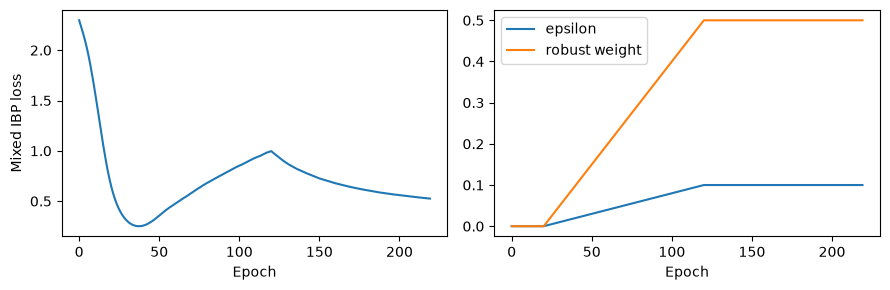

In [14]:
ibp_model=None
probe=ibp_bounds(baseline,Xe[:2],Xe[:2])
if probe is None or ibp_robust_loss(torch.zeros(2,10),torch.zeros(2,10),torch.tensor([0,1])) is None:
    pending("D1/D2")
else:
    # Точный тест affine на всех вершинах 2D-прямоугольника.
    affine=nn.Sequential(nn.Linear(2,2)).double()
    with torch.no_grad():
        affine[0].weight.copy_(torch.tensor([[1.,-2.],[-3.,4.]],dtype=torch.float64))
        affine[0].bias.copy_(torch.tensor([.5,-.5],dtype=torch.float64))
    lo=torch.tensor([[-1.,2.]],dtype=torch.float64); hi=torch.tensor([[2.,3.]],dtype=torch.float64)
    bl,bu=ibp_bounds(affine,lo,hi)
    corners=torch.tensor([[-1.,2.],[-1.,3.],[2.,2.],[2.,3.]],dtype=torch.float64)
    zz=affine(corners)
    torch.testing.assert_close(bl[0],zz.min(0).values)
    torch.testing.assert_close(bu[0],zz.max(0).values)
    relu=nn.Sequential(nn.ReLU())
    rl,ru=ibp_bounds(relu,torch.tensor([[-1.,2.]]),torch.tensor([[3.,4.]]))
    torch.testing.assert_close(rl,torch.tensor([[0.,2.]]))
    torch.testing.assert_close(ru,torch.tensor([[3.,4.]]))
    try:
        ibp_bounds(nn.Sequential(nn.Sigmoid()),torch.zeros(1,2),torch.ones(1,2))
        raise AssertionError("Unknown layer was silently accepted")
    except TypeError:
        pass
    l0,u0=probe
    torch.testing.assert_close(l0,baseline(Xe[:2]),rtol=1e-5,atol=1e-6)
    torch.testing.assert_close(l0,u0)
    torch.testing.assert_close(ibp_robust_loss(l0,u0,Ye[:2]),F.cross_entropy(baseline(Xe[:2]),Ye[:2]))
    # Случайные проверки включения НЕ заменяют математического доказательства.
    lo=(Xe[:8]-EPS).clamp(0,1); hi=(Xe[:8]+EPS).clamp(0,1)
    lb,ub=ibp_bounds(baseline,lo,hi)
    upper_loss=ibp_robust_loss(lb,ub,Ye[:8])
    for _ in range(30):
        xr=lo+(hi-lo)*torch.rand_like(lo)
        z=baseline(xr)
        assert (z>=lb-1e-5).all() and (z<=ub+1e-5).all()
        assert F.cross_entropy(z,Ye[:8])<=upper_loss+1e-5
    print("IBP: affine corners, ReLU, zero radius, inclusion and loss checks OK")
    ibp_model=make_model()
    optimizer=torch.optim.Adam(ibp_model.parameters(),lr=.01,weight_decay=1e-4)
    ibp_hist=[]
    for epoch in range(220):
        ramp=float(np.clip((epoch-20)/100,0,1))
        eps_now=EPS*ramp
        robust_weight=.5*ramp
        lower,upper=ibp_bounds(ibp_model,(Xtr-eps_now).clamp(0,1),(Xtr+eps_now).clamp(0,1))
        optimizer.zero_grad()
        loss=(1-robust_weight)*F.cross_entropy(ibp_model(Xtr),Ytr)+robust_weight*ibp_robust_loss(lower,upper,Ytr)
        loss.backward(); optimizer.step()
        ibp_hist.append({"epoch":epoch,"loss":loss.item(),"epsilon":eps_now,"robust_weight":robust_weight})
    ibp_model.eval(); models["IBP-trained"]=ibp_model
    fig,ax=plt.subplots(1,2,figsize=(9,3))
    h=pd.DataFrame(ibp_hist)
    ax[0].plot(h.epoch,h.loss); ax[0].set(xlabel="Epoch",ylabel="Mixed IBP loss")
    ax[1].plot(h.epoch,h.epsilon,label="epsilon")
    ax[1].plot(h.epoch,h.robust_weight,label="robust weight")
    ax[1].legend(); ax[1].set_xlabel("Epoch")
    plt.tight_layout(); plt.show()

Здесь мы пытаемся оптимизировать самый худший сдвиг изображения. Если нижняя граница правильного класса выже верхних границ неправильных классов, то мы получаем сертификат устойчивости на любом возмущении в пределах epsilon (в границах которого мы искали интервалы)

## E. Единый аудит: certified ≤ true robust ≤ empirical attack accuracy

Детерминированные модели сравниваются на одних и тех же 160 записях и L∞ eps=0.10.
Собираем union ошибок clean, FGSM, PGD-CE и PGD-margin, поэтому ни один обнаруженный
контрпример не теряется. Сильнейший проверенный пакет остаётся только верхней оценкой
истинной robust accuracy, не доказательством.

Для IBP-сертификатов считаем границы копии модели в float64 и требуем зазор >1e-9.
Это учебная численная реализация формул, а не промышленный верификатор с направленным округлением.
Полная гарантия для произвольных погрешностей floating point здесь не заявляется.

,model,N,clean_accuracy,FGSM_accuracy,PGD10_CE_accuracy,PGD30_CE_accuracy,PGD30_margin_accuracy,union_attack_accuracy,ASR_on_clean_correct,clean_correct_n,IBP_certified_accuracy,unknown_fraction,counterexample_fraction
0,ERM,160,0.96250,0.48750,0.53750,0.44375,0.46250,0.44375,0.538961,154,0.0000,0.44375,0.55625
1,AT,160,0.96875,0.71875,0.78125,0.70625,0.72500,0.70625,0.270968,155,0.0000,0.70625,0.29375
2,KD,160,0.97500,0.48750,0.53750,0.42500,0.45000,0.42500,0.564103,156,0.0000,0.42500,0.57500
3,Defensive KD,160,0.97500,0.66875,0.68125,0.53750,0.40625,0.40625,0.583333,156,0.0000,0.40625,0.59375
4,IBP-trained,160,0.94375,0.75000,0.75625,0.73125,0.73750,0.73125,0.225166,151,0.6625,0.06875,0.26875


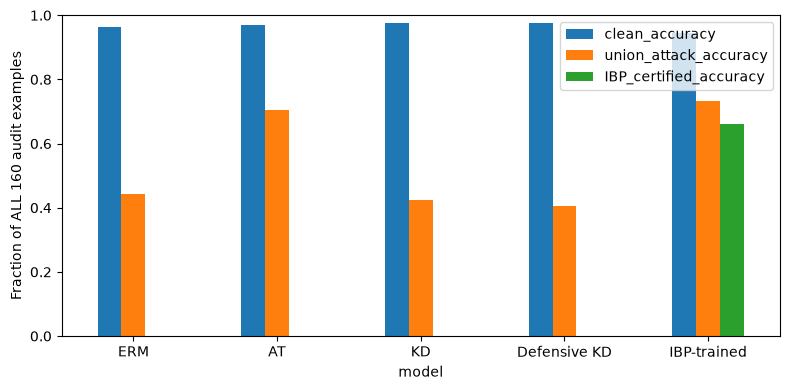

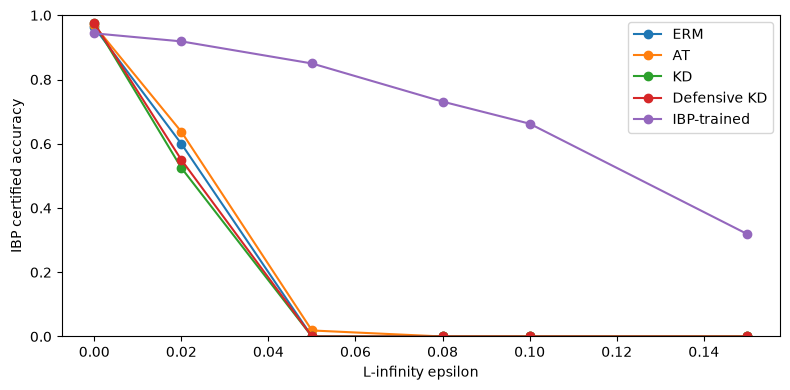

In [15]:
def ibp_certified(model,x,y,eps):
    if ibp_bounds(model,x[:1],x[:1]) is None: return None
    m64=copy.deepcopy(model).double().eval()
    with torch.no_grad():
        xd=x.double()
        lo,hi=ibp_bounds(m64,(xd-eps).clamp(0,1),(xd+eps).clamp(0,1))
        mask=F.one_hot(y,num_classes=10).bool()
        margin=lo.gather(1,y[:,None]).squeeze(1)-hi.masked_fill(mask,-torch.inf).max(1).values
        cert=margin>1e-9
    return cert,margin

audit_rows=[]
if project_linf(Xe[:1],Xe[:1],EPS) is None:
    pending("Final attack audit")
else:
    for name,model in models.items():
        correct=predict(model,Xe)==Ye
        survived=correct.clone()
        row={"model":name,"N":len(Xe),"clean_accuracy":correct.float().mean().item()}
        configs=[("FGSM",1,1,EPS,"ce",False),
                 ("PGD10_CE",10,2,.01,"ce",True),
                 ("PGD30_CE",30,2,.01,"ce",True),
                 ("PGD30_margin",30,2,.01,"margin",True)]
        pgd10_bad=None
        for aname,steps,restarts,step,kind,rs in configs:
            adv=pgd(model,Xe,Ye,EPS,steps,restarts,step,kind,seed=90,random_start=rs)
            assert (adv-Xe).abs().max()<=EPS+1e-6 and adv.min()>=0 and adv.max()<=1
            bad=predict(model,adv)!=Ye
            if aname=="PGD10_CE": pgd10_bad=bad
            if aname=="PGD30_CE": assert not (pgd10_bad & ~bad).any()
            survived &= ~bad
            row[aname+"_accuracy"]=(~bad).float().mean().item()
        row["union_attack_accuracy"]=survived.float().mean().item()
        row["ASR_on_clean_correct"]=(correct&~survived).sum().item()/max(1,correct.sum().item())
        row["clean_correct_n"]=int(correct.sum())
        assert row["union_attack_accuracy"]<=row["clean_accuracy"]+1e-6
        cert_result=ibp_certified(model,Xe,Ye,EPS)
        if cert_result is not None:
            cert,margin=cert_result
            assert not (cert&~correct).any()
            assert not (cert&~survived).any(), "Certificate contradicts an attack: inspect implementation!"
            row["IBP_certified_accuracy"]=cert.float().mean().item()
            row["unknown_fraction"]=(survived&~cert).float().mean().item()
            row["counterexample_fraction"]=(~survived).float().mean().item()
        audit_rows.append(row)
    results["audit"]=audit_rows
    audit=pd.DataFrame(audit_rows)
    display(audit)
    cols=["clean_accuracy","union_attack_accuracy"]
    if "IBP_certified_accuracy" in audit: cols.append("IBP_certified_accuracy")
    audit.set_index("model")[cols].plot.bar(rot=0,ylim=(0,1))
    plt.ylabel("Fraction of ALL 160 audit examples"); plt.tight_layout(); plt.show()

if ibp_model is not None:
    cert_curves=[]
    for name,model in models.items():
        values=[]
        for eps in [0,.02,.05,.08,.10,.15]:
            cert,_=ibp_certified(model,Xe,Ye,eps)
            value=cert.float().mean().item()
            cert_curves.append({"model":name,"epsilon":eps,"certified_accuracy":value})
            values.append(value)
        assert np.all(np.diff(values)<=1e-6)
        plt.plot([0,.02,.05,.08,.10,.15],values,"o-",label=name)
    results["ibp_curves"]=cert_curves
    plt.xlabel("L-infinity epsilon"); plt.ylabel("IBP certified accuracy")
    plt.ylim(0,1); plt.legend(); plt.tight_layout(); plt.show()

### Разбор итоговой таблицы

Нулевая IBP certified accuracy обычной модели не означает, что она неустойчива на каждом объекте.
Если атака не нашла ошибку, но bound не доказал устойчивость, ответ: UNKNOWN.
Если исходная классификация неверна, контрпримером уже является delta=0.
Для положительного сертификата относительно истинного класса нужна и корректность.

Эта таблица НЕ сравнивает smoothing с остальными методами: там другой классификатор g,
норма L2 и поднабор из 60 записей. Прямое сравнение одинаковых чисел epsilon и R некорректно.
В 64 измерениях достаточный переход L2→L∞ использует R/8 и строгое неравенство.

## Задание E1. Отчёт и расширение 

Основной отчёт (10 баллов) должен включать модель угроз, таблицу результатов,
объяснение границ certified/true robust/empirical, один отрицательный результат и цену защиты.
Не называйте loss-bound adversarial example, а Monte Carlo vote сертификатом без confidence bound.

Выберите ОДНО исследование до просмотра итогового test.

- **AT**: 3 seed; сравните число тренировочных PGD-шагов 1 и 5 при неизменной сильной evaluation-атаке.
- **KD**: 3 seed; температуры 1, 4, 10 и одинаковая архитектура; вывод делайте по union атак, не по confidence.
- **Smoothing**: n=500/2000/5000; при добавлении конфигураций пересчитайте alpha_each для всей фиксированной семьи.
- **IBP**: 3 seed; сравните abrupt epsilon=0.10 и ramp-up, измерьте clean/empirical/certified accuracy.

Данные для настройки берите из validation или отдельного development-стенда.
Среднее ± sample SD по seed не является доверительным интервалом.
В smoothing не переиспользуйте selection-голоса как estimation-выборку.

### Вопросы 

- Почему adversarial training с PGD не доказывает устойчивость к любому допустимому возмущению?
- Почему softmax(z) и softmax(100z) имеют одну границу argmax, но разные градиенты вероятностей?
- Для какого классификатора действует сертификат smoothing?
- Почему выбор класса и оценка его вероятности используют разные выборки?
- Что означает alpha и чем она отличается от ошибки классификации?
- Почему IBP теряет зависимости между нейронами?
- Что означает UNKNOWN и почему его нельзя записывать как «атака найдена»?
- Почему устойчивость к L∞ evasion не является защитой от poisoning или membership inference?

### Сдача

Сдайте заполненный `.ipynb` с таблицами и графиками, параметры атак/сертификатов, seed и версии среды,
а также краткое заключение до 2 страниц. 
Пропущенные блоки и None-заглушки не являются выполненными заданиями.

In [16]:
expected=["ERM","AT","KD","Defensive KD","IBP-trained"]
missing=[name for name in expected if name not in models]
if smooth_table is None: missing.append("Smoothing")
if "audit" not in results: missing.append("Attack audit")
print("Модели:",list(models))
print("Незавершённые разделы:",missing)
print(f"Время вычислений: {time.perf_counter()-START:.1f} с")
# При необходимости:
# from pathlib import Path
# Path("lecture10_results.json").write_text(json.dumps(results,ensure_ascii=False,indent=2),encoding="utf-8")

Модели: ['ERM', 'AT', 'KD', 'Defensive KD', 'IBP-trained']
Незавершённые разделы: []
Время вычислений: 7057.7 с


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xtr = Xtr.to(device)
Ytr = Ytr.to(device)

Xe = Xe.to(device)
Ye = Ye.to(device)

print("Device:", device)

Device: cpu



Training: mode=abrupt, seed=1
  clean     = 0.2313
  empirical = 0.1813
  certified = 0.0812
  counterex = 0.8188
  unknown   = 0.1000

Training: mode=abrupt, seed=2
  clean     = 0.1000
  empirical = 0.1000
  certified = 0.1000
  counterex = 0.9000
  unknown   = 0.0000

Training: mode=abrupt, seed=3
  clean     = 0.1000
  empirical = 0.1000
  certified = 0.1000
  counterex = 0.9000
  unknown   = 0.0000

Training: mode=ramp, seed=1
  clean     = 0.9500
  empirical = 0.6375
  certified = 0.3812
  counterex = 0.3625
  unknown   = 0.2562

Training: mode=ramp, seed=2
  clean     = 0.9438
  empirical = 0.6750
  certified = 0.3812
  counterex = 0.3250
  unknown   = 0.2937

Training: mode=ramp, seed=3
  clean     = 0.9500
  empirical = 0.6687
  certified = 0.3438
  counterex = 0.3313
  unknown   = 0.3250

Per-seed results:


,mode,seed,clean_accuracy,union_attack_accuracy,ibp_certified_accuracy,counterexample_fraction,unknown_fraction
0,abrupt,1,0.23125,0.18125,0.08125,0.81875,0.10000
1,abrupt,2,0.10000,0.10000,0.10000,0.90000,0.00000
2,abrupt,3,0.10000,0.10000,0.10000,0.90000,0.00000
3,ramp,1,0.95000,0.63750,0.38125,0.36250,0.25625
4,ramp,2,0.94375,0.67500,0.38125,0.32500,0.29375
5,ramp,3,0.95000,0.66875,0.34375,0.33125,0.32500



Mean ± sample SD:


clean_accuracy           union_attack_accuracy            \
                 mean       std                  mean       std   
mode                                                              
abrupt       0.143750  0.075777              0.127083  0.046910   
ramp         0.947917  0.003608              0.660417  0.020091   

       ibp_certified_accuracy            
                         mean       std  
mode                                     
abrupt                0.09375  0.010825  
ramp                  0.36875  0.021651


E1 final summary:


,training,clean accuracy,empirical attack accuracy,IBP certified accuracy
0,abrupt,14.38 ± 7.58%,12.71 ± 4.69%,9.38 ± 1.08%
1,ramp,94.79 ± 0.36%,66.04 ± 2.01%,36.87 ± 2.17%


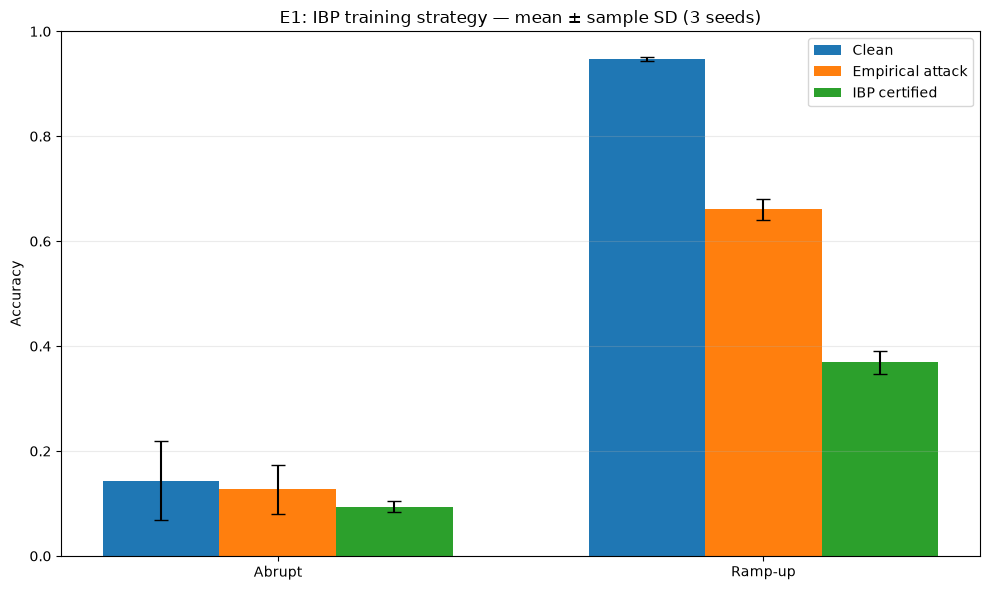

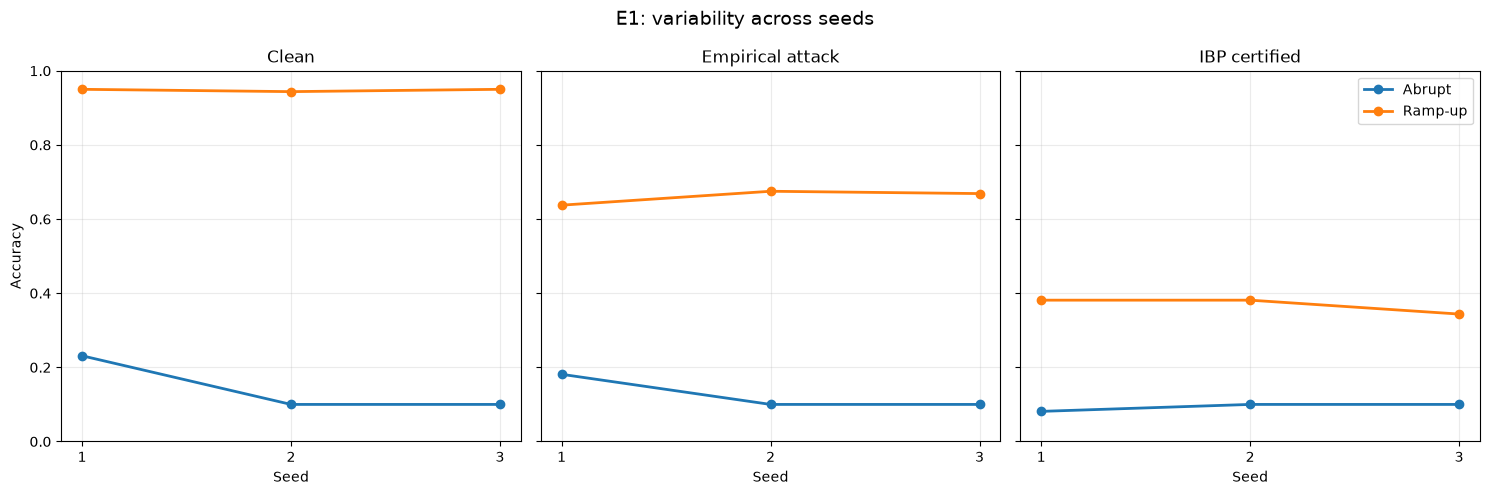

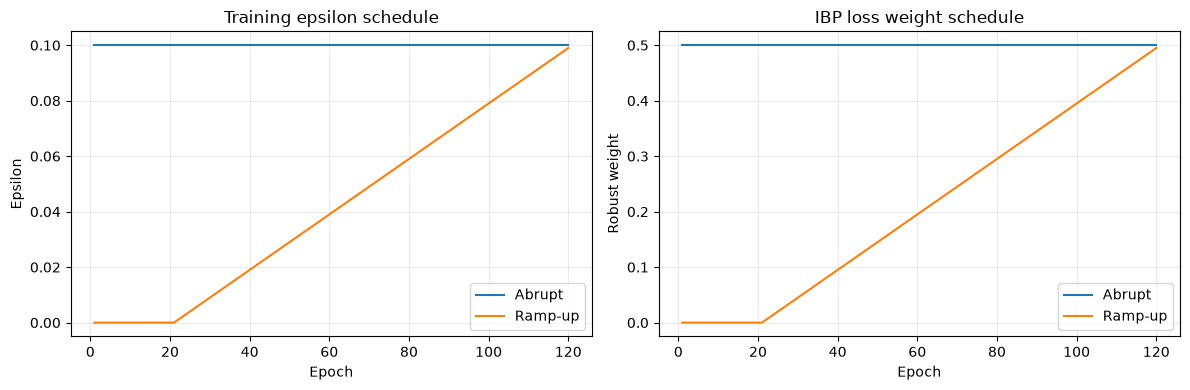

In [20]:
# ============================================================
# E1. IBP: abrupt epsilon=0.10 vs ramp-up
# 3 seeds, одинаковая архитектура и evaluation protocol
# ============================================================

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

E1_SEEDS = [1, 2, 3]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------
# 2. Model
# ------------------------------------------------------------

def make_model(seed):
    set_seed(seed)

    return nn.Sequential(
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 10)
    )


# ------------------------------------------------------------
# 3. IBP training
# ------------------------------------------------------------

def train_ibp_model(
    mode,
    seed,
    epochs=120,
    batch_size=64,
    lr=1e-3,
    eps=EPS,
    robust_weight_max=0.5
):
    """
    mode:
        "abrupt"  -> epsilon=EPS and robust_weight=0.5 from epoch 0
        "ramp"    -> epsilon and robust_weight increase gradually
    """

    assert mode in {"abrupt", "ramp"}

    set_seed(seed)

    model = make_model(seed).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    n = len(Xtr)

    history = {
        "epoch": [],
        "clean_loss": [],
        "ibp_loss": [],
        "total_loss": [],
        "epsilon": [],
        "robust_weight": []
    }

    for epoch in range(epochs):

        # ----------------------------------------------------
        # Training schedule
        # ----------------------------------------------------
        if mode == "abrupt":
            eps_now = eps
            robust_weight = robust_weight_max

        else:
            # Same ramp-up schedule as in the main IBP experiment
            ramp = min(1.0, max(0.0, (epoch - 20) / 100))

            eps_now = eps * ramp
            robust_weight = robust_weight_max * ramp

        # ----------------------------------------------------
        # Shuffle training data
        # ----------------------------------------------------
        perm = torch.randperm(n, device=Xtr.device)

        model.train()

        epoch_clean = 0.0
        epoch_ibp = 0.0
        epoch_total = 0.0
        seen = 0

        for start in range(0, n, batch_size):

            idx = perm[start:start + batch_size]

            xb = Xtr[idx]
            yb = Ytr[idx]

            optimizer.zero_grad()

            # Clean loss
            clean_logits = model(xb)
            clean_loss = F.cross_entropy(clean_logits, yb)

            # ------------------------------------------------
            # IBP loss
            # ------------------------------------------------
            if eps_now > 0:
                lower = torch.clamp(xb - eps_now, 0.0, 1.0)
                upper = torch.clamp(xb + eps_now, 0.0, 1.0)

                lower_logits, upper_logits = ibp_bounds(
                    model,
                    lower,
                    upper
                )

                ibp_loss = ibp_robust_loss(
                    lower_logits,
                    upper_logits,
                    yb
                )
            else:
                # At epsilon=0, IBP bounds collapse to the
                # clean logits.
                ibp_loss = clean_loss

            # Mixed objective
            total_loss = (
                (1.0 - robust_weight) * clean_loss
                + robust_weight * ibp_loss
            )

            total_loss.backward()
            optimizer.step()

            bs = len(yb)

            epoch_clean += clean_loss.item() * bs
            epoch_ibp += ibp_loss.item() * bs
            epoch_total += total_loss.item() * bs
            seen += bs

        history["epoch"].append(epoch + 1)
        history["clean_loss"].append(epoch_clean / seen)
        history["ibp_loss"].append(epoch_ibp / seen)
        history["total_loss"].append(epoch_total / seen)
        history["epsilon"].append(eps_now)
        history["robust_weight"].append(robust_weight)

    return model, pd.DataFrame(history)


# ------------------------------------------------------------
# 4. Evaluation attacks
# ------------------------------------------------------------

@torch.no_grad()
def clean_correct_mask(model, X, y):
    model.eval()
    pred = model(X).argmax(dim=1)
    return pred.eq(y)

def attack_failure_mask(model, X, y):
    model.eval()

    # FGSM = 1 шаг PGD, один restart, без random start
    x_fgsm = pgd(
        model, X, y,
        eps=EPS,
        steps=1,
        restarts=1,
        step_size=EPS,
        kind="ce",
        seed=123,
        random_start=False,
    )

    # PGD-10, CE
    x_pgd10 = pgd(
        model, X, y,
        eps=EPS,
        steps=10,
        restarts=2,
        step_size=EPS / 10,
        kind="ce",
        seed=123,
        random_start=True,
    )

    # PGD-30, CE
    x_pgd30_ce = pgd(
        model, X, y,
        eps=EPS,
        steps=30,
        restarts=2,
        step_size=EPS / 10,
        kind="ce",
        seed=123,
        random_start=True,
    )

    # PGD-30, margin
    x_pgd30_margin = pgd(
        model, X, y,
        eps=EPS,
        steps=30,
        restarts=2,
        step_size=EPS / 10,
        kind="margin",
        seed=123,
        random_start=True,
    )

    with torch.no_grad():
        broken = (
            (model(x_fgsm).argmax(1) != y)
            | (model(x_pgd10).argmax(1) != y)
            | (model(x_pgd30_ce).argmax(1) != y)
            | (model(x_pgd30_margin).argmax(1) != y)
        )

    return broken

# ------------------------------------------------------------
# 5. IBP certification
# ------------------------------------------------------------

def ibp_certified_mask(model, X, y, eps):
    """
    Certified iff:
        lower_y > max_{j != y} upper_j

    Float64 is used for a more stable numerical audit.
    """

    model64 = copy.deepcopy(model).double().eval()

    X64 = X.double()
    y64 = y

    lower = torch.clamp(X64 - eps, 0.0, 1.0)
    upper = torch.clamp(X64 + eps, 0.0, 1.0)

    with torch.no_grad():
        lower_logits, upper_logits = ibp_bounds(
            model64,
            lower,
            upper
        )

        true_lower = lower_logits[
            torch.arange(len(y64), device=y64.device),
            y64
        ]

        upper_other = upper_logits.clone()

        upper_other[
            torch.arange(len(y64), device=y64.device),
            y64
        ] = -torch.inf

        max_other = upper_other.max(dim=1).values

        margin = true_lower - max_other

        certified = margin > 1e-9

    return certified.cpu()


# ------------------------------------------------------------
# 6. Run all 6 models
# ------------------------------------------------------------

E1_results = []
E1_models = {}
E1_histories = {}

for mode in ["abrupt", "ramp"]:

    for seed in E1_SEEDS:

        print(f"\nTraining: mode={mode}, seed={seed}")

        model, history = train_ibp_model(
            mode=mode,
            seed=seed
        )

        E1_models[(mode, seed)] = model
        E1_histories[(mode, seed)] = history

        # ----------------------------------------------------
        # Clean accuracy
        # ----------------------------------------------------
        clean_mask = clean_correct_mask(
            model,
            Xe,
            Ye
        ).cpu()

        clean_accuracy = clean_mask.float().mean().item()

        # ----------------------------------------------------
        # Empirical attack evaluation
        # ----------------------------------------------------
        broken = attack_failure_mask(
            model,
            Xe,
            Ye
        ).cpu()

        union_attack_accuracy = (~broken).float().mean().item()

        # ----------------------------------------------------
        # Certified accuracy
        # ----------------------------------------------------
        certified = ibp_certified_mask(
            model,
            Xe,
            Ye,
            EPS
        )

        ibp_certified_accuracy = certified.float().mean().item()

        # ----------------------------------------------------
        # Additional useful quantities
        # ----------------------------------------------------
        counterexample_fraction = broken.float().mean().item()

        unknown_fraction = (
            (~broken & ~certified)
            .float()
            .mean()
            .item()
        )

        E1_results.append({
            "mode": mode,
            "seed": seed,
            "clean_accuracy": clean_accuracy,
            "union_attack_accuracy": union_attack_accuracy,
            "ibp_certified_accuracy": ibp_certified_accuracy,
            "counterexample_fraction": counterexample_fraction,
            "unknown_fraction": unknown_fraction
        })

        print(
            f"  clean     = {clean_accuracy:.4f}\n"
            f"  empirical = {union_attack_accuracy:.4f}\n"
            f"  certified = {ibp_certified_accuracy:.4f}\n"
            f"  counterex = {counterexample_fraction:.4f}\n"
            f"  unknown   = {unknown_fraction:.4f}"
        )


E1_df = pd.DataFrame(E1_results)

print("\nPer-seed results:")
display(E1_df)


# ------------------------------------------------------------
# 7. Mean ± sample SD
# ------------------------------------------------------------

metrics = [
    "clean_accuracy",
    "union_attack_accuracy",
    "ibp_certified_accuracy"
]

E1_summary = (
    E1_df
    .groupby("mode")[metrics]
    .agg(["mean", "std"])
)

print("\nMean ± sample SD:")
display(E1_summary)


# ------------------------------------------------------------
# 8. Nice formatted summary table
# ------------------------------------------------------------

summary_rows = []

for mode in ["abrupt", "ramp"]:

    row = {"mode": mode}

    for metric in metrics:

        mean = E1_df.loc[
            E1_df["mode"] == mode,
            metric
        ].mean()

        sd = E1_df.loc[
            E1_df["mode"] == mode,
            metric
        ].std(ddof=1)

        row[metric] = f"{100*mean:.2f} ± {100*sd:.2f}%"

    summary_rows.append(row)

E1_pretty = pd.DataFrame(summary_rows)

E1_pretty = E1_pretty.rename(columns={
    "mode": "training",
    "clean_accuracy": "clean accuracy",
    "union_attack_accuracy": "empirical attack accuracy",
    "ibp_certified_accuracy": "IBP certified accuracy"
})

print("\nE1 final summary:")
display(E1_pretty)


# ------------------------------------------------------------
# 9. Visualization 1:
#    mean ± sample SD
# ------------------------------------------------------------

plot_df = E1_df.groupby("mode")[metrics].agg(["mean", "std"])

modes = ["abrupt", "ramp"]
labels = ["Abrupt", "Ramp-up"]

x = np.arange(len(modes))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):

    means = [
        plot_df.loc[mode, (metric, "mean")]
        for mode in modes
    ]

    sds = [
        plot_df.loc[mode, (metric, "std")]
        for mode in modes
    ]

    ax.bar(
        x + (i - 1) * width,
        means,
        width,
        yerr=sds,
        capsize=5,
        label={
            "clean_accuracy": "Clean",
            "union_attack_accuracy": "Empirical attack",
            "ibp_certified_accuracy": "IBP certified"
        }[metric]
    )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title(
    "E1: IBP training strategy — mean ± sample SD (3 seeds)"
)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Visualization 2:
#     every seed separately
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharey=True
)

metric_labels = {
    "clean_accuracy": "Clean",
    "union_attack_accuracy": "Empirical attack",
    "ibp_certified_accuracy": "IBP certified"
}

for ax, metric in zip(axes, metrics):

    for mode, label in zip(["abrupt", "ramp"], ["Abrupt", "Ramp-up"]):

        vals = [
            E1_df.loc[
                (E1_df["mode"] == mode) &
                (E1_df["seed"] == seed),
                metric
            ].iloc[0]
            for seed in E1_SEEDS
        ]

        ax.plot(
            E1_SEEDS,
            vals,
            marker="o",
            linewidth=2,
            label=label
        )

    ax.set_title(metric_labels[metric])
    ax.set_xlabel("Seed")
    ax.set_xticks(E1_SEEDS)
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Accuracy")
axes[-1].legend()

fig.suptitle(
    "E1: variability across seeds",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Optional visualization 3:
#     training schedules themselves
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4)
)

# epsilon schedule
for mode, label in zip(["abrupt", "ramp"], ["Abrupt", "Ramp-up"]):

    history = E1_histories[(mode, E1_SEEDS[0])]

    axes[0].plot(
        history["epoch"],
        history["epsilon"],
        label=label
    )

axes[0].set_title("Training epsilon schedule")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Epsilon")
axes[0].grid(alpha=0.25)
axes[0].legend()

# robust weight schedule
for mode, label in zip(["abrupt", "ramp"], ["Abrupt", "Ramp-up"]):

    history = E1_histories[(mode, E1_SEEDS[0])]

    axes[1].plot(
        history["epoch"],
        history["robust_weight"],
        label=label
    )

axes[1].set_title("IBP loss weight schedule")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Robust weight")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()